In [17]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.0  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

Hartree-Fock能量: -1.06610865 Ha
FCI能量: -1.10115033 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [18]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [19]:
hi.all_states()

Array([[0, 1, 0, 1],
       [0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0]], dtype=int8)

In [20]:
from flax import nnx
from jax.nn.initializers import lecun_normal
from typing import Any
import jax
from functools import partial
import jax.numpy as jnp

DType = Any
default_kernel_init = lecun_normal()


class LogNeuralBackflow(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

        # Construct the Backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
        # that modifies the bare orbitals.
        self.backflow = nnx.Sequential(
            # First layer, input (..., N,) output (..., hidden_units)
            nnx.Linear(
                in_features=hilbert.size,
                out_features=hidden_units,
                param_dtype=param_dtype,
                rngs=rngs,
            ),
            nnx.tanh,
            # Last layer, input (..., hidden_units,) output (..., N x Nf)
            nnx.Linear(
                in_features=hidden_units,
                out_features=hilbert.n_orbitals * hilbert.n_fermions,
                param_dtype=param_dtype,
                rngs=rngs,
            ),
            # Reshape into the orbital shape, (..., N, Nf)
            lambda x: x.reshape(
                x.shape[:-1] + (hilbert.n_orbitals, hilbert.n_fermions)
            ),
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Construct the Backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
            # that modifies the bare orbitals.
            F = self.backflow(n)
            # Add the backflow correction to the bare orbitals
            M = self.M + F

            # Find the positions of the occupied, backflow-modified orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            A = M[R]
            return _logdet_cmplx(A)

        return log_sd(n)


def _logdet_cmplx(A):
    # 计算复数矩阵的行列式的对数
    return jnp.linalg.slogdet(A)[1]

In [21]:
N = 4
backflow_model = LogNeuralBackflow(hi, hidden_units=N, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, backflow_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_backflow"

In [22]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:11<00:00, 25.81it/s, Energy=-1.066e+00 ± 9.813e-18 [σ²=4.930e-32, R̂=0.9843]]


(JsonLog('h2_molecule_backflow', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.05076742172241211
   	Params: 0.05320906639099121,)

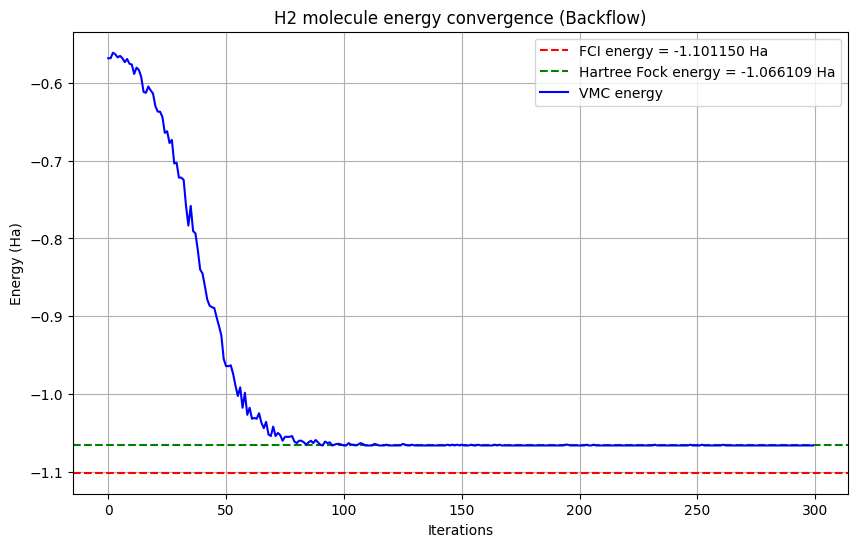


最终VMC能量: -1.06610865 Ha
与FCI能量误差: 0.03504168 Ha
与Hartree-Fock能量误差: 0.00000000 Ha


In [23]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence (Backflow)")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
print(f"与Hartree-Fock能量误差: {abs(y[-1] - E_hf):.8f} Ha")

In [24]:
# 假设 vs 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vs.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")

组态及其概率分布:
组态(轨道占据)    概率      物理解释
--------------------------------------------------
[1 0 1 0]         0.999900   电子占据轨道: [0 2]
[1 0 0 1]         0.000100   电子占据轨道: [0 3]
